# Ensemble Kaggle branch

In this notebook we process te image input and train an ensemble model with 
different arquitectures

In [1]:
# --- Imports & config ---
from pathlib import Path
import numpy as np
import pandas as pd
import torch.nn as nn
import timm
import os
import random
import copy
import matplotlib.pyplot as plt
import time, torch
from torch.utils.data import WeightedRandomSampler, DataLoader
from tqdm import tqdm
from torch import amp
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import sys
sys.path.append("../utils")
from utils import create_balanced_split , ISIC_Multimodal_Dataset

# configure all:
class config:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data_dir = Path("../data")
    models_dir = Path("../models")
    utils_dir = Path("../utils")
    train_meta_csv = data_dir / "train-metadata.csv"
    test_meta_csv = data_dir / "test-metadata.csv"
    train_hdf5 = data_dir / "train-image.hdf5"
    test_hdf5 = data_dir / "test-image.hdf5"
    meta_procesor = utils_dir / "metadata_processor.pkl"
    metamodel_path = utils_dir / "metamodel.plk"
    hairs_path = utils_dir / "hairs"
    lr = 1e5
    mean = [0.485, 0.456, 0.406],
    std = [0.229, 0.224, 0.225],
    seed = 42
    image_size = 224
    epochs = 50
    batch_size = 64
    num_imgs_epoch = 3000
    target_epoch_proportion = 0.50
    BCE_loss_pos_weight = 1
    ratio_neg_pos = 20
    val_split = 0.2             # of train
    num_feat = 0                # 0 = use all
    fine_tuning_batch = 30      # batch to train ensemble models
    val_freq = 1                # frequency of validation analisis
    attention_dim = 256         # dimension of trained attention ensemble

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed_everything(config.seed)

/home/pawn/anaconda3/envs/aprendizaje/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and analyze the data

Because of the extreme class imbalance in the dataset (approximately 0.01 vs 99.99), we follow two strategies. First, we limit the ratio of healthy lesions included during training: instead of using the full 400,000 benign images, we use a controlled ratio of 25 benign samples per malignant sample. Second, we apply targeted data augmentation to malignant class (class 1) examples to increase their effective variability and reduce overfitting.

For class 1 (malignant lesions), we apply medically appropriate augmentations inspired by the recommendations in Mahbod et al., *"Effects of augmentation strategies on skin lesion classification"* (2019). Their study demonstrates that carefully selected geometric and photometric transformations improve melanoma classification performance while avoiding unrealistic distortions.

Below is a summary of the augmentation pipeline used in this work.

### Data Augmentation for Skin Lesion Classification (ISIC)

To improve model generalization in skin lesion classification, we apply a set of medically validated data augmentations. These transformations simulate real-world acquisition variability, including differences in camera systems, zoom levels, lighting conditions, focus, rotation, and minor occlusions such as hair or ruler marks.

A brief explanation of each augmentation follows.

1. Resize → RandomResizedCrop
Images are first resized for consistent input dimensions. A random crop (90%–100% of the area) is then extracted.
*Purpose*: Simulates variation in zoom and framing across dermoscopy systems.


2. Random Rotation (±15°)
Applies small rotations without distorting the lesion structure.
*Purpose*: Lesions do not have a fixed orientation; rotation increases representation diversity.


3. Horizontal Flip
Mirrors the image horizontally.
*Purpose*: Human anatomy is largely symmetric; lesion appearance remains valid under flipping.


4. ColorJitter
Applies light variations in brightness, contrast, saturation, and hue.
*Purpose*: Models differences across dermatoscopes, lighting conditions, and skin tones.

5. RandomAdjustSharpness
Applies slight sharpening at random.
*Purpose*: Simulates variability in optical focus and imaging quality.

6. Gaussian Blur
Adds small blur variations.
*Purpose*: Reproduces the behavior of different dermoscopic camera systems.

7. RandomErasing
Erases a small random region of the image.
*Purpose*: Simulates occlusions such as hair, bubbles, ruler artifacts, or pen marks.

8. Normalize (ImageNet mean/std)
Standard normalization used with ImageNet-pretrained CNNs.

#### Scientific Support

These augmentations are supported by dermatology-focused studies, particularly:

**Mahbod et al., "Effects of augmentation strategies on skin lesion classification" (2019)**  
This work shows that:
- light geometric transformations,  
- controlled color perturbations,  
- blur and sharpness adjustments,  
- and occlusion-based augmentations  
consistently improve melanoma classification accuracy across ISIC datasets.

Link: https://arxiv.org/abs/1910.05351

---

Together, these augmentations increase robustness, reduce overfitting, and help compensate for the limited number of malignant samples in the dataset.


In [2]:
import cv2
import albumentations as A
from utils import AdvancedHairAugmentation, Microscope

train_transform = A.Compose([
    A.OneOf([
        A.ShiftScaleRotate(scale_limit=0.15, rotate_limit=80, shift_limit=0.1,
                           border_mode=cv2.BORDER_REPLICATE, p=0.5),
        A.Affine(shear=20, p=0.5),  # 'mode' eliminado
        A.Perspective(p=0.5),
    ], p=0.5),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Resize(config.image_size, config.image_size),

    AdvancedHairAugmentation(hairs=10, hairs_folder=config.hairs_path, p=0.5),
    A.RandomBrightnessContrast(),

    # CoarseDropout nuevo: usa num_holes, max_height, max_width
    A.CoarseDropout(num_holes_range=(1, 8),
                    hole_height_range=(0.1, 0.25),
                    hole_width_range=(0.1, 0.25), 
                    fill=0, p=0.3),
    Microscope(p=0.1),

    # Normalize nuevo: no usar always_apply
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0))
])

val_transform = A.Compose([
    A.Resize(config.image_size, config.image_size),
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0))
])

/home/pawn/anaconda3/envs/aprendizaje/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/home/pawn/Desktop/deep_learning/ISIC_DL/src/../utils/utils.py:356: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)


In [3]:
from utils import get_best_metadata, MetadataProcessor
import joblib

# 1º Create a split of train and validation balanced
# we dont need all the images
train_df, val_df, df_balanced = create_balanced_split(
    config.train_meta_csv,
    neg_multiplier=config.ratio_neg_pos,      # conservative ratio of 25:1 
    val_frac=config.val_split            # split a 20% of train to validation
)
test_df = pd.read_csv(config.test_meta_csv, low_memory=False)

# 2º Create the augmented test and validation datasets
if Path(config.meta_procesor).exists():
    metadata_processor =joblib.load(config.meta_procesor)
else:
    best_features = get_best_metadata(train_df, test_df, num_feat=config.num_feat, verbose=True)
    metadata_processor = MetadataProcessor(best_features)
    metadata_processor.fit(pd.read_csv(config.train_meta_csv))
    joblib.dump(metadata_processor, config.meta_procesor)



train_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=config.train_hdf5,
    metadata_df=train_df,
    image_transform=train_transform,
    metadata_processor=metadata_processor
)

val_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=config.train_hdf5,
    metadata_df=val_df,
    image_transform=val_transform,
    metadata_processor=metadata_processor
)

test_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=config.test_hdf5,
    metadata_df=test_df,
    image_transform=val_transform,
    metadata_processor=metadata_processor
)

/home/pawn/Desktop/deep_learning/ISIC_DL/src/../utils/utils.py:99: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(metadataCSV_path)


Positives: 343
Negatives available: 400616
Negatives to sample: 6860

Balanced dataset size: 7203
target
0    6860
1     343
Name: count, dtype: int64


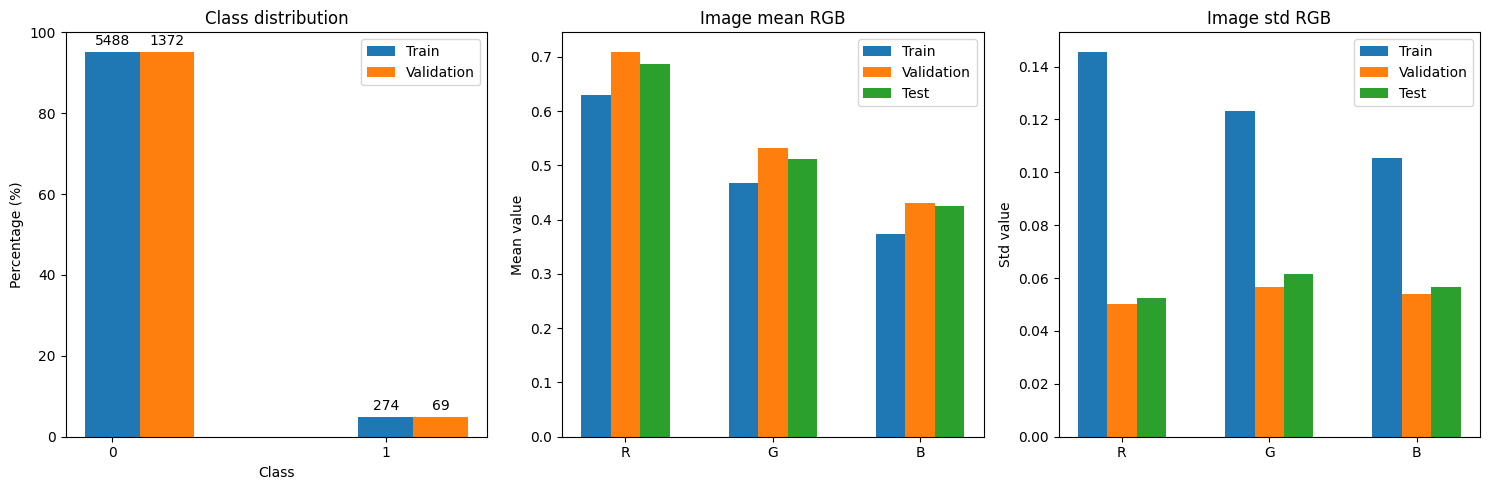

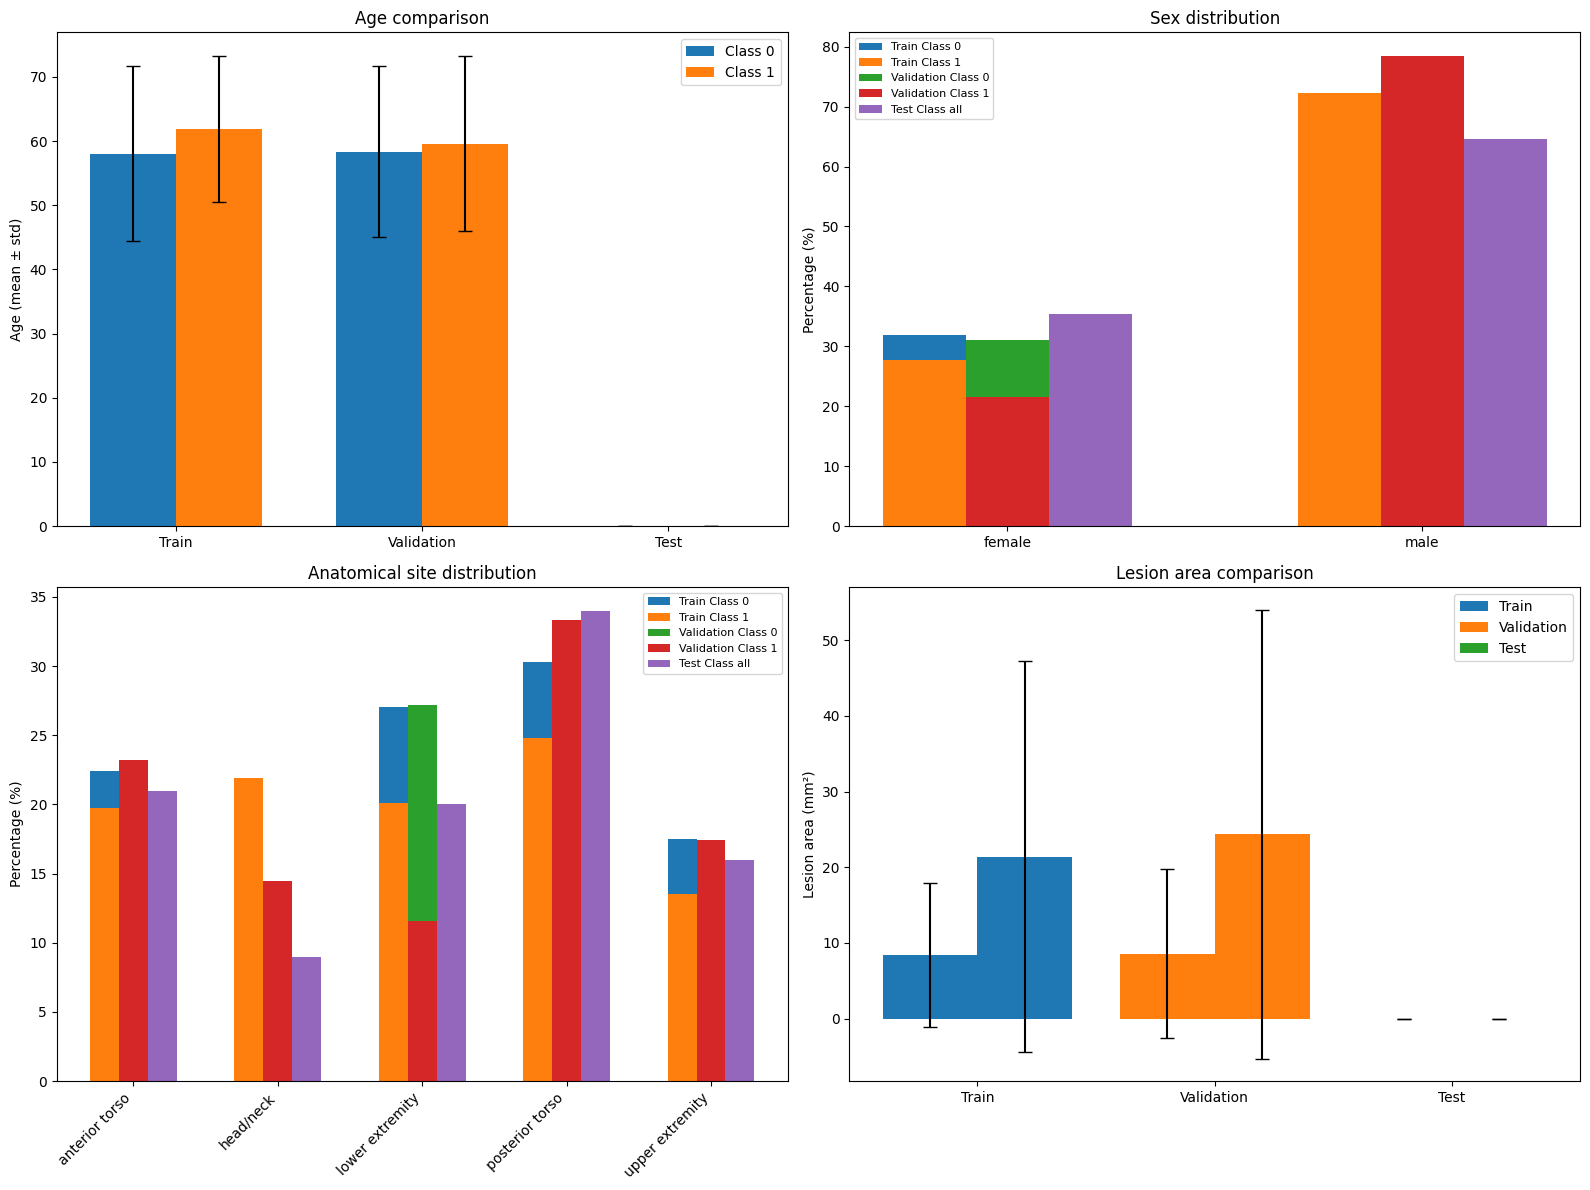

In [4]:
from utils import plot_stats

train_stats = train_dataset.get_dataset_stats(sample_size=300)
val_stats   = val_dataset.get_dataset_stats(sample_size=300)
test_stats  = test_dataset.get_dataset_stats(sample_size=300)
stats_list = [train_stats, val_stats, test_stats]

# Now we compare the analisis of the splits
plot_stats(stats_list)

## DataLoaders

We calculate the **ratio of the weighted sampler** using the formula:
$$
w_{c1}=\frac{p_{target}}{1-p_{target}}\frac{n_{c1}}{n_{c2}}
$$
so in the example we want $ p_{target} = 0.25 $
$$
w_{c1}=\frac{0.25}{0.75}\frac{20}{1}
$$

For the weights of the loss functions is as follows:
$$
pos_w=\frac{1-p_{posImg}}{p_{posImg}}
$$

In [5]:
from utils import make_sampler_weights

# Get the weights for the sampler
multimodal_train_targets = train_dataset.metadata['target'].values
sample_weights = make_sampler_weights(
    multimodal_train_targets, 
    config.target_epoch_proportion)

# Create the weighted sampler with the calculated weights
multimodal_weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=config.num_imgs_epoch,
    replacement=True
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    sampler=multimodal_weighted_sampler,
    num_workers=4,
    pin_memory=True if config.device == 'cuda' else False
)

valid_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True if config.device == 'cuda' else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True if config.device == 'cuda' else False
)

print("📦 Multimodal data loaders created with balanced sampling!")


📦 Multimodal data loaders created with balanced sampling!


# Backbone

In [6]:
from utils import TrainableModule, remove_last_layer    

class EmbeddingHead(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super().__init__()
        self.pre_norm = nn.BatchNorm1d(input_dim)
        self.fc = nn.Sequential(
            nn.Linear(input_dim, emb_dim),
            nn.GELU(),
            nn.BatchNorm1d(emb_dim),
            nn.Dropout(0.2),
            nn.Linear(emb_dim, emb_dim),
            nn.GELU(),
            nn.BatchNorm1d(emb_dim),
            nn.Dropout(0.2),
        )
    
    def forward(self, x):
        x = self.pre_norm(x)
        x = self.fc(x)
        return x / (x.norm(dim=1, keepdim=True) + 1e-6)
    
class CombinedHead(nn.Module):
    def __init__(self, img_dim, meta_dim, hidden_dim=512, out_dim=1, dropout=0.5):
        super().__init__()
        self.img_fc = nn.Sequential(
            nn.Linear(img_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.meta_fc = nn.Sequential(
            nn.Linear(meta_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.combined_fc = nn.Sequential(
            nn.Linear(hidden_dim*2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
            nn.Sigmoid()
        )
    
    def forward(self, img_feat, meta_feat):
        img_out = self.img_fc(img_feat)
        meta_out = self.meta_fc(meta_feat)
        combined = torch.cat([img_out, meta_out], dim=1)
        out = self.combined_fc(combined)
        return out
    
class PretrainedClassifier(nn.Module):
    def __init__(self, device, model_name, model_origin, metadata_model, 
                 num_classes=1, attn_dim = 256):
        super().__init__()

        self.attn_dim = attn_dim

        # ----- Backbone for the image ------
        if model_origin == ".pt":
            self.backbone = torch.load(model_name)
            # change last layer
            self.backbone = remove_last_layer(self.backbone)

        elif model_origin == "timm":
            self.backbone = timm.create_model(
                model_name,
                pretrained=True,
                global_pool='avg',
                num_classes=0  # don't use the original detection head
            )

        # add a trainable head to the backbone
        self.backbone.to(device)
        self.device = device
        with torch.no_grad():
            dummy_img = torch.zeros(1, 3, 224, 224).to(device)
            img_feat = self.backbone(dummy_img)
        self.img_dim = img_feat.shape[1]

        # freeze the backbone
        # for p in self.backbone.parameters():
        #     p.requires_grad = False

        self.backbone_head = EmbeddingHead(self.img_dim, self.attn_dim//2).to(device)

        # ----- pretrained model for metadata ------
        self.metadata_model = metadata_model
        self.metadata_head = EmbeddingHead(2, emb_dim=attn_dim//2).to(device)

        # ----- Final combining head ------
        self.combining_head = CombinedHead(
            img_dim=attn_dim // 2,
            meta_dim=attn_dim // 2,
            hidden_dim=256,
            out_dim=num_classes,
            dropout=0.5
        ).to(device)

    def forward(self, images, metadata):
        # ---- Image embedding ----
        backbone_img = self.backbone(images)
        feat_img = self.backbone_head(backbone_img)       # (B, attn_dim/2)

        # ---- Metadata embedding ----
        with torch.no_grad():
            metadata_np = metadata.detach().cpu().numpy()
            leaf_prob_np = self.metadata_model.predict_proba(metadata_np)
            # print(f"leaf_prob_np max: {leaf_prob_np.max()}")
            leaf_prob_np = np.clip(leaf_prob_np, 1e-6, 1 - 1e-6)
        leaf_prob = torch.from_numpy(leaf_prob_np).float().to(self.device)

        # ---- Concatenate for attention ----
        feat_meta = self.metadata_head(leaf_prob)         # (B, attn_dim/2)
        # print(f"max_feat: {feat_meta.max()} min: {feat_meta.min()}")
        # print(f"feat_img: {feat_img.max()} min: {feat_img.min()}")
        out = self.combining_head(feat_img, feat_meta)
        # print(f"out: {out.max()} min: {out.min()}")
        return out


class PretrainedClassifierExtended(PretrainedClassifier, TrainableModule):
    def __init__(self, device, model_name, model_origin, metadata_model,
                 lr, criterion, val_freq=5, attn_dim=256, patience=5, min_delta=0.01):
        PretrainedClassifier.__init__(self, device, model_name, model_origin, 
                                      metadata_model, attn_dim=attn_dim)
        TrainableModule.__init__(self, criterion, device, patience, min_delta)

        self.name = model_name
        self.model_origin = model_origin
        self.val_freq = val_freq    # freq of validation metrics
        self.lr=lr
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_auc": []
        }

    def fit(self, train_loader, val_loader=None, epochs=10):
        print(f"----------------------------------------")
        print(f"       Training {self.name}")
        print(f"----------------------------------------")

        self.optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, self.parameters()),
            lr=self.lr)

        for epoch in range(1, epochs+1):
            torch.cuda.empty_cache()
            start = time.time()
            print(f"Epoch {epoch}/{epochs}: ", end="")

            train_loss, per_pos = self._train_epoch(train_loader)
            self.history["train_loss"].append(train_loss)
            print(f"Train loss: {train_loss:.4f} || percentaje pos in epoch: {per_pos:.3f}%")

            if val_loader and epoch%self.val_freq==0:
                val_loss, val_auc = self._validate(val_loader)
                self.history["val_loss"].append(val_loss)
                self.history["val_auc"].append(val_auc)
                print(f"Val Loss: {val_loss:.4f} | AUC: {val_auc:.4f}", end="")

                # save the best arquitecture
                if self.best_model_AUC < val_auc:
                    self.best_model_AUC = val_auc
                    self.best_model = copy.deepcopy(self.state_dict())

                if self._check_early_stopping(val_loss):
                    self.load_state_dict(self.best_state_dict)
                    self.to(self.device)
                    return  # exit for early stopping
            
            print(f" in {time.time() - start:.2f}s")
    
    @classmethod
    def load(cls, path, device, model_name, model_origin, metadata_model, 
             criterion, **kwargs):
        model = cls(device, model_name, model_origin, metadata_model, criterion, **kwargs)
        model.load_state_dict(torch.load(path, map_location=device))
        model.to(device)
        return model


### Train the mix models

In [7]:
print(timm.list_models())

['aimv2_1b_patch14_224', 'aimv2_1b_patch14_336', 'aimv2_1b_patch14_448', 'aimv2_3b_patch14_224', 'aimv2_3b_patch14_336', 'aimv2_3b_patch14_448', 'aimv2_huge_patch14_224', 'aimv2_huge_patch14_336', 'aimv2_huge_patch14_448', 'aimv2_large_patch14_224', 'aimv2_large_patch14_336', 'aimv2_large_patch14_448', 'bat_resnext26ts', 'beit3_base_patch16_224', 'beit3_giant_patch14_224', 'beit3_giant_patch14_336', 'beit3_large_patch16_224', 'beit_base_patch16_224', 'beit_base_patch16_384', 'beit_large_patch16_224', 'beit_large_patch16_384', 'beit_large_patch16_512', 'beitv2_base_patch16_224', 'beitv2_large_patch16_224', 'botnet26t_256', 'botnet50ts_256', 'caformer_b36', 'caformer_m36', 'caformer_s18', 'caformer_s36', 'cait_m36_384', 'cait_m48_448', 'cait_s24_224', 'cait_s24_384', 'cait_s36_384', 'cait_xs24_384', 'cait_xxs24_224', 'cait_xxs24_384', 'cait_xxs36_224', 'cait_xxs36_384', 'coat_lite_medium', 'coat_lite_medium_384', 'coat_lite_mini', 'coat_lite_small', 'coat_lite_tiny', 'coat_mini', 'coat_s

In [8]:
from utils import pretrain_metadata_model
# -------------------------------------------------------------------------------
# 0º Pre-train metadata model
# -------------------------------------------------------------------------------
# warnings.filterwarnings("ignore")
# optuna.logging.set_verbosity(optuna.logging.WARNING)
meta_model = pretrain_metadata_model(train_df, metadata_processor, 
                                     save_path=config.metamodel_path, verbose=True)

# Number of features coming from metadata
num_metadata_features = metadata_processor.transform(test_df).shape[1]

# -------------------------------------------------------------------------------
# 1º Define loss and model list
# -------------------------------------------------------------------------------
pos_weights = torch.tensor(config.BCE_loss_pos_weight).to(config.device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

model_paths = ["efficientnet_b0", "efficientnet_b1", "efficientnet_b2", "efficientnet_b3"]# ["efficient_net_f0", "efficient_net_f1", "efficient_net_f2", "efficient_net_f3", "efficient_net_f4"]
model_types = ["timm", "timm", "timm", "timm"]# [".pt", ".pt", ".pt", ".pt", ".pt"]

model_list = []

# -------------------------------------------------------------------------------
# 2º Train / load ensemble models
# -------------------------------------------------------------------------------
for i, (model_name, model_orig) in enumerate(zip(model_paths, model_types)):

    save_path = f"{config.models_dir}/{model_name}.pt"

    if model_name + ".pt" not in os.listdir(config.models_dir):
        print(f"\n⏳ Training {model_name} ...")

        model = PretrainedClassifierExtended(
            model_name=model_name,
            model_origin=model_orig,
            metadata_model=meta_model,
            lr=config.lr,
            criterion=criterion,
            device=config.device,
            patience=config.fine_tuning_batch,
            val_freq=config.val_freq,
            attn_dim=config.attention_dim)

        model.fit(train_loader, valid_loader, epochs=config.fine_tuning_batch)

        model.save(save_path)

    else:
        print(f"📂 {model_name} loaded from memory")

        model = PretrainedClassifierExtended(
            model_name=model_name,
            model_origin=model_orig,
            metadata_model=meta_model,
            lr=config.lr,
            criterion=criterion,
            device=config.device,
            patience=config.fine_tuning_batch,
            val_freq=config.val_freq,
            attn_dim=config.attention_dim)
        model.load(save_path)

    model_list.append(model)


Loading pretrained metadata model from: ../utils/metamodel.plk

⏳ Training efficientnet_b0 ...
----------------------------------------
       Training efficientnet_b0
----------------------------------------
Epoch 1/30: 

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 5.67 GiB of which 1.31 MiB is free. Including non-PyTorch memory, this process has 5.55 GiB memory in use. Of the allocated memory 5.31 GiB is allocated by PyTorch, and 99.84 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### Now we wrap the ensemble and models with a train function

In [ ]:
class EnsembleClassifier(nn.Module):
    def __init__(self, models, models_type, hidden_dim=64):
        super().__init__()

        # Freeze base models
        self.models = nn.ModuleList(models)
        self.num_models = len(models)
        for m in self.models:
            for p in m.parameters():
                p.requires_grad = False
            m.eval()

        self.models_type = models_type

        # get the number and propierties of models
        output_dims = [
            self.get_output_dim(m, t, device) 
            for m, t in zip(self.models, self.models_type)
        ]

        self.meta_input_dim = sum(output_dims)

        # ------------ Meta-model ("stacker") ----------------
        self.meta_model = nn.Sequential(
            nn.Linear(self.meta_input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    # ---------------------------------------------------------
    def forward(self, image, metadata):

        base_preds = []
        for m, mtype in zip(self.models, self.models_type):
            if mtype == "mix":
                preds = m(image, metadata)      # (batch, 1)
            elif mtype == "img":
                preds = m(image)
            elif mtype == "meta":
                preds = m(metadata)
            else:
                raise ValueError(f"Invalid type_input: {metadata}")
            
            if preds is None:
                raise RuntimeError("ERROR: A model returned None.")

            
            base_preds.append(preds)

        # concatenate the logits: shape → (batch, num_models)
        base_preds = torch.cat(base_preds, dim=1)

        # Process the model
        out = self.meta_model(base_preds)
        return out

    def get_output_dim(self, model, mtype, device):
        """Run a single dummy forward pass to infer output dimension."""
        
        model.eval()

        with torch.no_grad():
            if mtype == "img":
                dummy_img = torch.randn(1, 3, 224, 224).to(device)
                out = model(dummy_img)

            elif mtype == "meta":
                dummy_meta = torch.randn(1, self.metadata_dim).to(device)
                out = model(dummy_meta)

            elif mtype == "mix":
                dummy_img = torch.randn(1, 3, 224, 224).to(device)
                dummy_meta = torch.randn(1, self.metadata_dim).to(device)
                out = model(dummy_img, dummy_meta)

            else:
                raise ValueError("Invalid model type")
        
        return out.view(1, -1).shape[1]

In [ ]:
from utils import TrainableModule
from sklearn.metrics import roc_auc_score


class EnsembleClassifierExtended(EnsembleClassifier, TrainableModule):
    def __init__(self, models, models_type, criterion, device,
                 patience=10, min_delta=0.01, num_epoc_val=5):
        EnsembleClassifier.__init__(self, models, models_type)
        TrainableModule.__init__(self, criterion, device, patience, min_delta)

        self.val_epoc = num_epoc_val
        # metrics
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_auc": [],
            "ensembles_val_auc": []
        }

    def fit(self, train_loader, val_loader=None, epochs=10):

        for epoch in range(1, epochs+1):
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
            start = time.time()
            print(f"\nEpoch {epoch}/{epochs}: ", end="")

            train_loss, per_pos = self._train_epoch(train_loader)
            self.history["train_loss"].append(train_loss)
            print(f"Train loss: {train_loss:.4f} || percentaje pos in epoch: {per_pos}%")


            if val_loader and epoch%self.val_epoc==0:
                val_loss, val_auc, ensemble_aucs = self._validate(val_loader)
                self.history["val_loss"].append(val_loss)
                self.history["val_auc"].append(val_auc)
                self.history["ensembles_val_auc"].append(ensemble_aucs)
                print(f"\tVal Loss: {val_loss:.4f} | AUC: {val_auc:.4f}", end="")

                # save the best arquitecture
                if self.best_model_AUC < val_auc:
                    self.best_model_AUC = val_auc
                    self.best_model = copy.deepcopy(self.state_dict())

                if self._check_early_stopping(val_loss):
                    self.load_state_dict(self.best_state_dict)
                    self.to(self.device)
                    return  # exit for early stopping
                
            torch.cuda.synchronize()
            print(f" in {time.time() - start:.2f}s")

    def _validate(self, loader):
        self.eval()
        total_loss = 0
        preds_list = []
        labels_list = []
        model_aucs = []

        with torch.no_grad():
            # calculate each model in ensemble roc auc
            for model, m_type in zip(self.models, self.models_type):
                model.eval()
                preds_model = []
                labels_model = []
                for images, metadata, labels, _ in loader:
                    images = images.to(self.device, non_blocking=True)
                    metadata = metadata.to(self.device, non_blocking=True)
                    labels = labels.float().to(self.device, non_blocking=True)

                    with amp.autocast(device_type=self.device.type):  # AMP
                        logits = self.forward_single(model, m_type, images, metadata)
                        probs = torch.sigmoid(logits)              # (B, K)
                        probs = probs.mean(dim=1)                  # (B,)  ← una predicción por imagen

                        preds_model.extend(probs.cpu().numpy().tolist())
                        labels_model.extend(labels.cpu().numpy().tolist())

                preds_model = np.array(preds_model)
                labels_model = np.array(labels_model)
                auc = roc_auc_score(labels_model, preds_model)
                model_aucs.append(auc)
            
            # calculate the combined roc auc
            for images, metadata, labels, _ in loader:
                images = images.to(self.device, non_blocking=True)
                metadata = metadata.to(self.device, non_blocking=True)
                labels = labels.float().to(self.device, non_blocking=True)

                with amp.autocast(device_type=self.device.type):  # AMP
                    preds = self(images, metadata).squeeze()
                    loss = self.criterion(preds, labels)
                total_loss += loss.item()

                preds_list.append(preds.cpu())
                labels_list.append(labels.cpu())

        # update ensemble weights
        self.weights_ens = [a / sum(model_aucs) for a in model_aucs]

        preds = torch.cat(preds_list).sigmoid().numpy()
        labels = torch.cat(labels_list).numpy()
        auc_ensemble = roc_auc_score(labels, preds)

        return total_loss / len(loader), auc_ensemble, model_aucs
    
    def forward_single(self, model, mtype, images, metadata):
        if mtype == "img":
            return model(images)
        elif mtype == "meta":
            return model(metadata)
        elif mtype == "mix":
            return model(images, metadata)
        else:
            raise ValueError(f"Invalid model type: {mtype}")

    # -------------------------------------------------------------
    def submit_kaggle(self, test_loader, submission_file="submission.csv"):
        """
        Generate Kaggle submission CSV using ensemble predictions.

        Parameters:
        -----------
        test_loader : DataLoader
            Test dataset loader. Should yield (images, metadata, isic_ids) or (images, isic_ids)
        submission_file : str
            Output CSV filename

        Returns:
        --------
        submission_df : pd.DataFrame
            DataFrame containing 'isic_id' and 'target' columns
        """
        self.eval()
        predictions = []

        with torch.no_grad():
            for images, metadata, isic_ids in tqdm(test_loader, desc="Inference on Test"):
                images = images.to(self.device, non_blocking=True)
                metadata = metadata.to(self.device, non_blocking=True)

                with amp.autocast(device_type=self.device.type):  # AMP
                    logits = self(images, metadata).squeeze()
                    probs = torch.sigmoid(logits)
                
                probs = probs.cpu().numpy()
                for isic_id, p in zip(isic_ids, probs):
                    predictions.append({"isic_id": isic_id, "target": float(p)})

        submission_df = pd.DataFrame(predictions)
        submission_df = submission_df.sort_values(by="isic_id").reset_index(drop=True)

        submission_file = "submission.csv"
        submission_df.to_csv(submission_file, index=False)

        print(f"Saved submission with {len(submission_df)} rows to {submission_file}")
        display(submission_df.head(10))

    # -------------------------------------------------------------
    @classmethod
    def load(cls, path, model_name, metadata_dim, criterion, device):
        model = cls(model_name, metadata_dim, criterion, device)
        model.load_state_dict(torch.load(path, map_location=device))
        model.to(device)
        return model


# Train

efficientnet_b4,
efficientnet_b0,
resnet18,
resnet50,
vgg13,
vgg16,
vit_tiny_patch16_224.augreg_in21k_ft_in1k

In [ ]:
#-------------------------------------------------------------------------------
# 2º Define the parámeters and the enseble 
#-------------------------------------------------------------------------------
model_name = "Ensemble"

model_names = ["efficient_net_f0", 
               "efficient_net_f1", 
               "efficient_net_f2", 
               "efficient_net_f3", 
               "efficient_net_f4"]

models_paths = [MODELS_DIR / (name + '.pt') for name in model_names]

def load_models(paths):
    models = []
    for path in paths:
        model = torch.jit.load(path, map_location=device)
        models.append(model)

    return models

models = load_models(models_paths)

print("\n/////////////////// FITTING ENSEMBLE  ///////////////////\n")
ensemble_class = EnsembleClassifierExtended(
                    models=models,
                    models_type=["img", "img", "img"],
                    criterion=criterion,
                    device=device, 
                    min_delta=1e-4,
                    patience=NUM_EPOCH)

ensemble_class.fit(train_loader, valid_loader, epochs=NUM_EPOCH)
# save the model trained
ensemble_class.save(model_path)

# if model_name+".pth" not in os.listdir(MODELS_DIR):

# else: # load from memory
#     print(f"model {model_path} loaded from memory")
#     model = PretrainedClassifierExtended(
#         model_name=model_names[i], 
#         metadata_dim=num_metadata_features,
#         criterion=criterion,
#         device=device)
#     model.load(model_path)


/////////////////// FITTING ENSEMBLE  ///////////////////



/home/pawn/Desktop/deep_learning/ISIC_DL/src/../utils/utils.py:462: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = amp.GradScaler() if device.type == "cuda" else None



Epoch 1/60: 

Train loss: 0.7640 || percentaje pos in epoch: 0.5003333333333333%
 in 44.71s

Epoch 2/60: 

Train loss: 0.7242 || percentaje pos in epoch: 0.49766666666666665%
 in 36.84s

Epoch 3/60: 

...

Train loss: 0.6507 || percentaje pos in epoch: 0.5133333333333333%
 in 30.25s

Epoch 29/60: 

Train loss: 0.6551 || percentaje pos in epoch: 0.5056666666666667%
 in 31.35s

Epoch 30/60: 

Train loss: 0.6480 || percentaje pos in epoch: 0.49566666666666664%
	Val Loss: 0.6761 | AUC: 0.6422 in 95.28s

Epoch 31/60: 

Train loss: 0.6526 || percentaje pos in epoch: 0.507%
 in 32.55s

Epoch 32/60: 

KeyboardInterrupt: 

### Plot the results of the train

In [ ]:
# conffusion matrix of all models and the ensemble
n_models = len(model_names)
total_plots = n_models + 1  # including ensemble

fig, axes = plt.subplots(1, total_plots, figsize=(5*total_plots, 5))

# Plot individual models
for i, model in enumerate(model_list):
    labels, preds, _ = model.pred_probs(valid_loader)
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot(ax=axes[i], cmap=plt.cm.Blues, values_format='d')
    axes[i].set_title(model_names[i])

# Plot ensemble
labels, preds, _ = ensemble_class.pred_probs(valid_loader)
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(ax=axes[-1], cmap=plt.cm.Blues, values_format='d')
axes[-1].set_title("Ensemble")

plt.tight_layout()
plt.show()

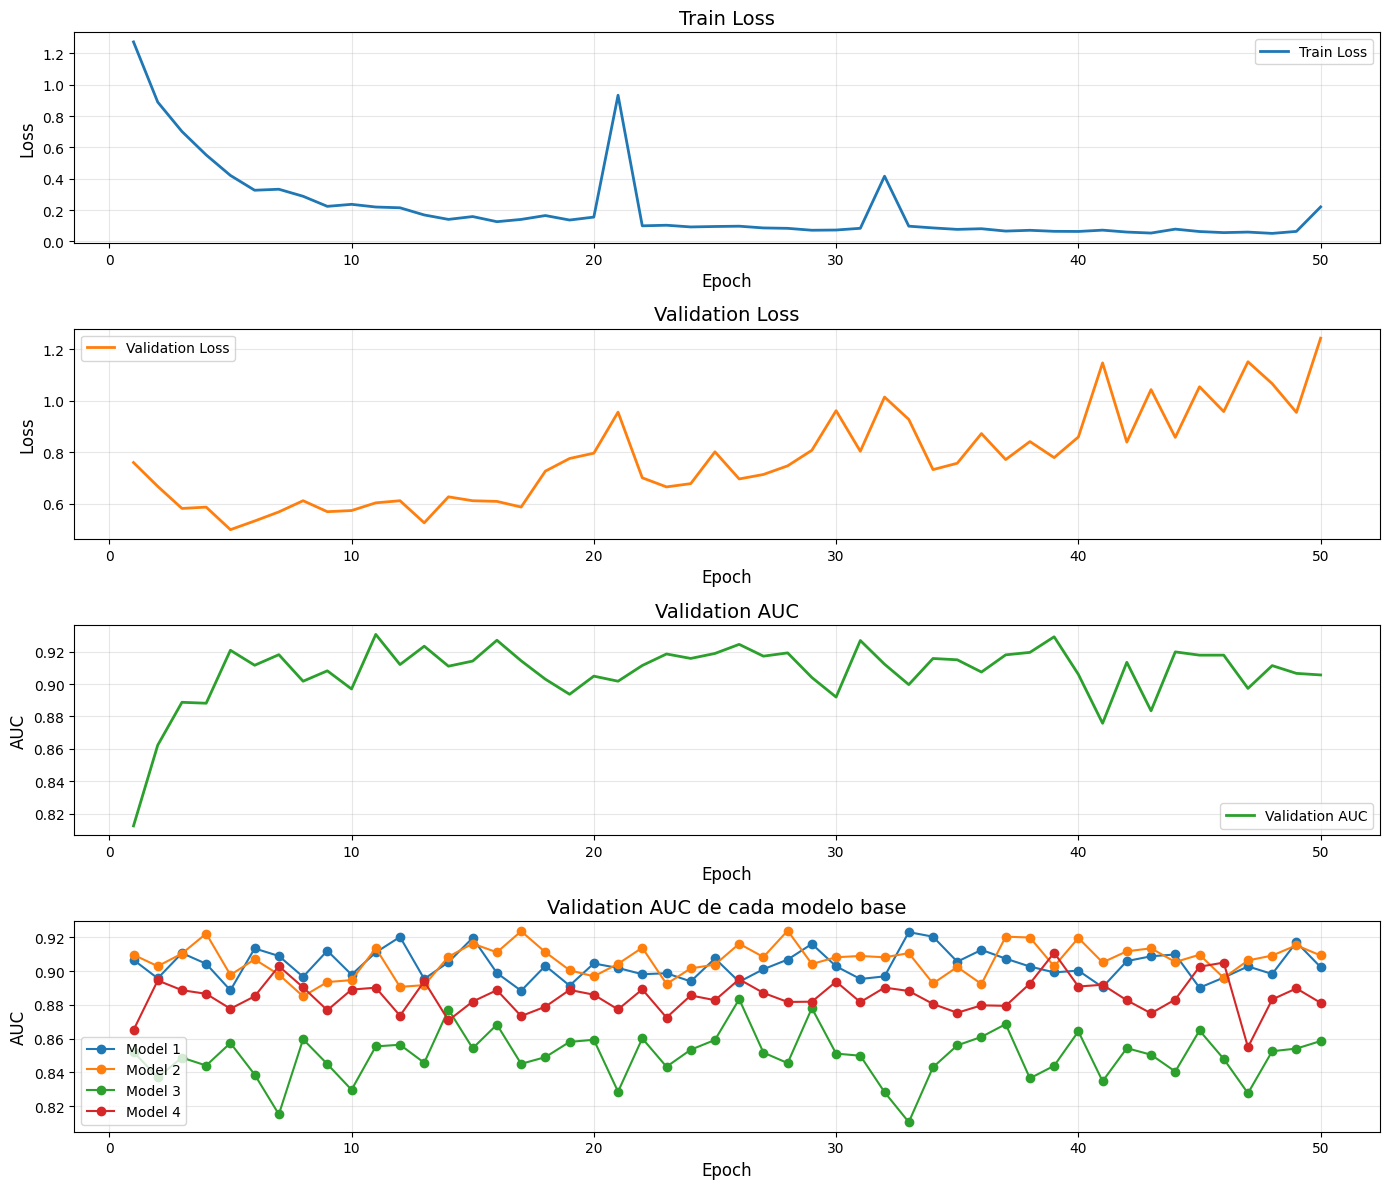

In [ ]:
train_loss = ensemble_class.history["train_loss"]
val_loss = ensemble_class.history["val_loss"]
val_auc = ensemble_class.history["val_auc"]
ensemble_model_aucs = ensemble_class.history.get("ensembles_val_auc", [])

epochs = np.arange(1, len(train_loss) + 1)

plt.figure(figsize=(14, 12))

# 1. TRAIN LOSS
plt.subplot(4, 1, 1)
plt.plot(epochs, train_loss, label="Train Loss", color="tab:blue", linewidth=2)
plt.title("Train Loss", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

# 2. VALIDATION LOSS
plt.subplot(4, 1, 2)
plt.plot(epochs, val_loss, label="Validation Loss", color="tab:orange", linewidth=2)
plt.title("Validation Loss", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

# 3. VALIDATION AUC
plt.subplot(4, 1, 3)
plt.plot(epochs, val_auc, label="Validation AUC", color="tab:green", linewidth=2)
plt.title("Validation AUC", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("AUC", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(4, 1, 4)
if ensemble_model_aucs:
    ensemble_model_aucs = np.array(ensemble_model_aucs)  # shape [epochs, n_models]
    n_models = ensemble_model_aucs.shape[1]
    for i in range(n_models):
        plt.plot(epochs, ensemble_model_aucs[:, i], marker='o', label=f'Model {i+1}')
    plt.title("Validation AUC de cada modelo base", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("AUC", fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

### kaggle submission generation

In [ ]:
ensemble_class.submit_kaggle(test_loader, submission_file="submission.csv")

Inference on Test:   0%|          | 0/2 [00:00<?, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x76 and 77x128)